In [1]:
# libraries for data loading and plotting
import matplotlib.pyplot as plt
import json
import pandas as pd
import numpy as np

In [2]:
# load augmentation assessments for ner
with open("augmentations_ner/eval_results/metrics_datasetsize.json", "r") as f:
    metrics_dataset_size = json.load(f)
with open("augmentations_ner/eval_results/metrics_augmentations.json", "r") as f:
    metrics_augmentations_ner = json.load(f)

# load oversampling assessments for stance classification
with open("oversampling_stance/eval_results/metrics_original_data.json", "r") as f:
    metrics_original_data = json.load(f)
with open("oversampling_stance/eval_results/metrics_aug_only_negative.json", "r") as f:
    metrics_only_negative = json.load(f)
with open("oversampling_stance/eval_results/metrics_aug_minority_classes.json", "r") as f:
    metrics_minority_classes = json.load(f)
with open("oversampling_stance/eval_results/metrics_aug_prop.json", "r") as f:
    metrics_proportional = json.load(f)

# combine metrics in one dictionary
metrics_bound = {"original_data": metrics_original_data[0],
                 "only_negative": metrics_only_negative[0],
                 "minority_classes": metrics_minority_classes[0],
                 "proportional": metrics_proportional[0]}

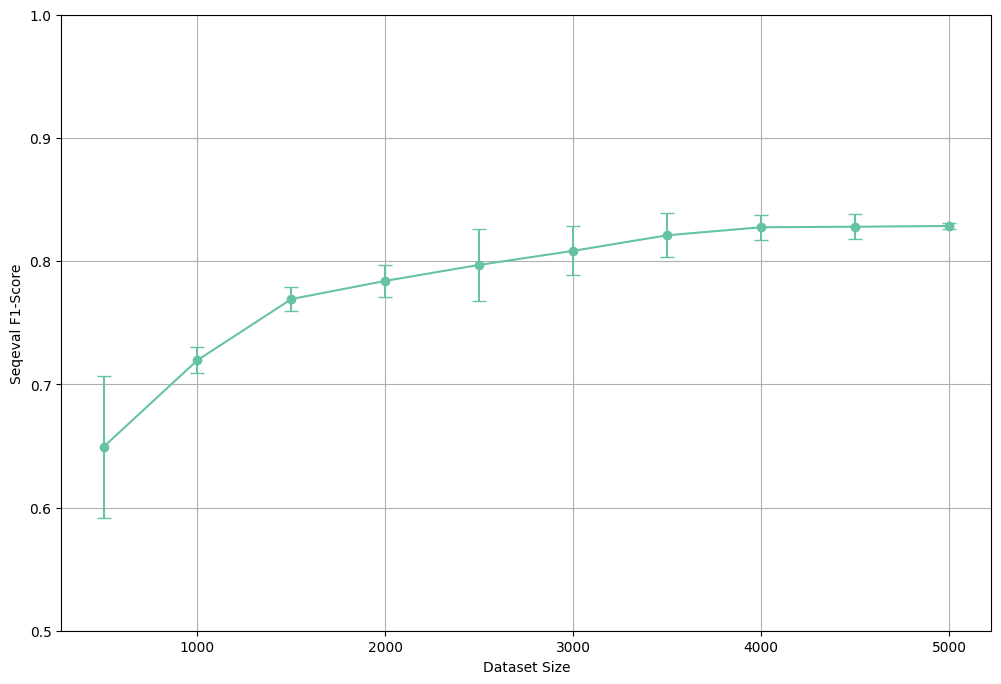

In [3]:
# extract fields from dictionary results
def extract(values):
    sizes = [d["dataset_size"] for d in values]
    means = [d["mean_seqeval"] for d in values]
    lower = [d["ci_lower"] for d in values]
    upper = [d["ci_upper"] for d in values]
    return np.array(sizes), np.array(means), np.array(lower), np.array(upper)

sizes, means, lower, upper = extract(metrics_dataset_size)
yerr_lower = means - lower
yerr_upper = upper - means
yerr = np.array([yerr_lower, yerr_upper])

# plot development of seqeval f1-score
color_scheme = plt.cm.Set2.colors
plt.figure(figsize=(12,8))
plt.errorbar(sizes, means, yerr=yerr, linestyle="-", fmt="o", markersize=6, capsize=5, color=color_scheme[0])
#plt.title("Cross-Validated Model Performance with Increasing Dataset Size")
plt.xlabel("Dataset Size")
plt.ylabel("Seqeval F1-Score")
plt.ylim(0.5, 1)
plt.grid(True)
plt.show()

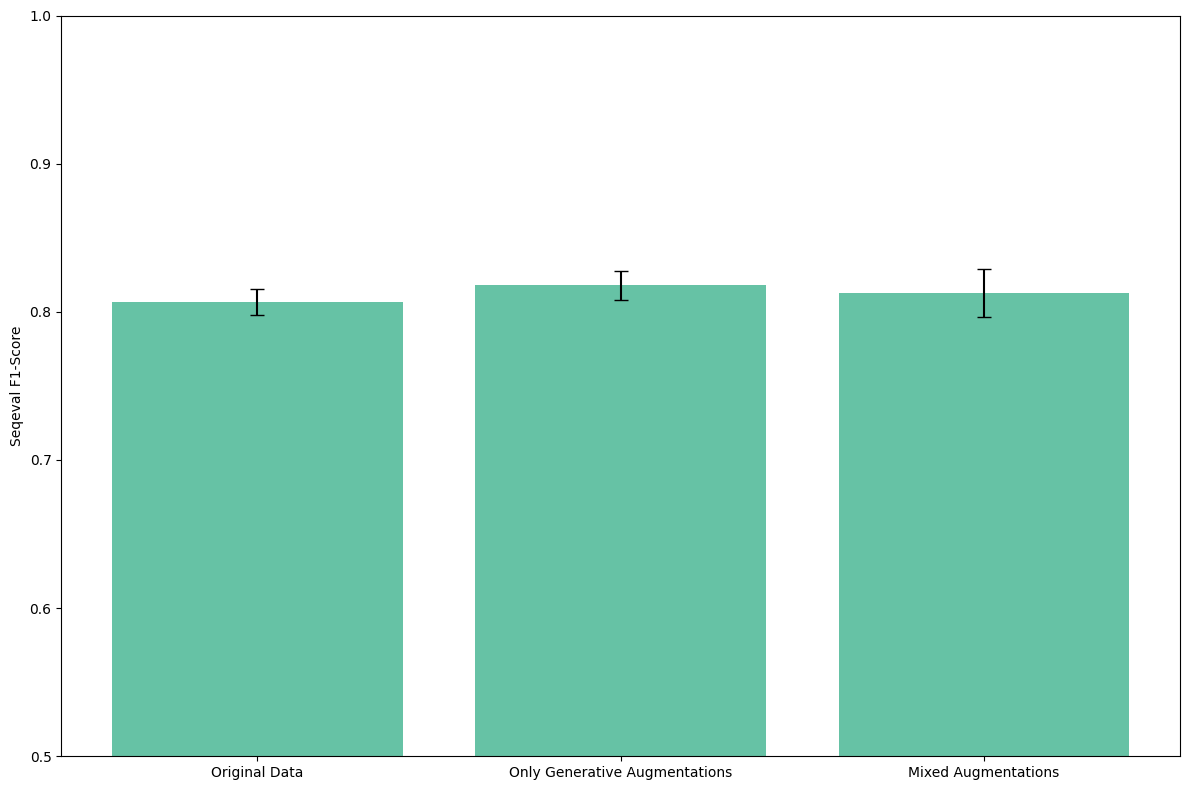

In [4]:
# convert dictionary to a df
rows = []
for method, stats in metrics_augmentations_ner[0].items():
    rows.append({
        "method": method,
        "mean": stats["mean_seqeval"],
        "error": stats["mean_seqeval"] - stats["ci_lower"]
    })
augmentations_ner_df = pd.DataFrame(rows)

# create the plot
plt.figure(figsize=(12, 8))
plt.bar(
   augmentations_ner_df["method"],
   augmentations_ner_df["mean"],
   yerr=augmentations_ner_df["error"],
   capsize=5,
   color=color_scheme[0]
)
# plt.errorbar(
#     augmentations_ner_df["method"],
#     augmentations_ner_df["mean"],
#     yerr=augmentations_ner_df["error"],
#     fmt="o",
#     markersize=6,
#     capsize=5,
#     color=color_scheme[0]
# )
plt.xticks(
    augmentations_ner_df["method"],
    ["Original Data", "Only Generative Augmentations", "Mixed Augmentations"]
)
plt.ylabel("Seqeval F1-Score")
plt.ylim(0.5, 1)
#plt.title("Comparison of data augmentation strategies")
plt.tight_layout()
plt.show()


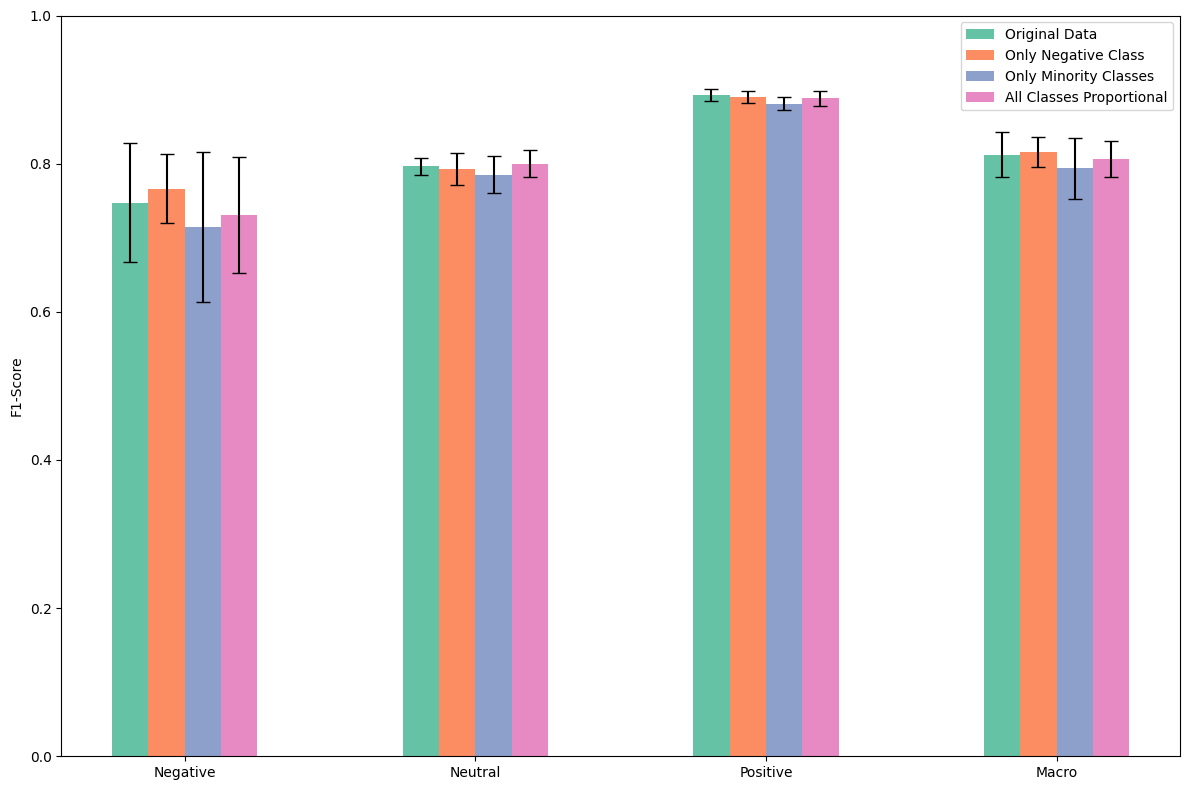

In [6]:
# turn dictionary into a wide df
rows = []
for method, entries in metrics_bound.items():
    entry = entries
    for label, stats in entry.items():
        rows.append({
            "method": method,
            "label": label,
            "mean": stats["mean"],
            "lower": stats["lower"],
            "upper": stats["upper"],
            "error": stats["mean"] - stats["lower"]
        })
augmentations_stance_df = pd.DataFrame(rows)

labels = augmentations_stance_df["label"].unique()
methods = augmentations_stance_df["method"].unique()

methods_remap = {
    "original_data": "Original Data", "only_negative": "Only Negative Class", "minority_classes": "Only Minority Classes", "proportional": "All Classes Proportional"
}
labels_remap = {
    "negative": "Negative", "neutral": "Neutral", "positive": "Positive", "macro_avg": "Macro"
}

x = np.arange(len(labels))
width = 0.5/len(methods)

fig, ax = plt.subplots(figsize=(12, 8))

for i, method in enumerate(methods):
    subset = augmentations_stance_df[augmentations_stance_df["method"] == method]
    subset = subset.set_index('label').reindex(labels)
    means = subset["mean"].values
    yerr_lower = subset['mean'] - subset['lower']
    yerr_upper = subset['upper'] - subset['mean']
    yerr = np.array([yerr_lower, yerr_upper])
    ax.bar(x+i*width, means, width, yerr=yerr, capsize=5, label=methods_remap[method], color=color_scheme[i%len(color_scheme)])

ax.set_xticks(x + width*(len(methods)-1)/2)
ax.set_xticklabels([labels_remap[l] for l in labels])
ax.set_ylim(0, 1)
ax.set_ylabel("F1-Score")
#ax.set_title("Performance of Different Augmentation Methods on F1-Score")
ax.legend()
plt.tight_layout()
plt.show()